In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

G, c, Msun = 6.674e-11, 2.998e8, 1.989e30
plt.rcParams['figure.dpi'] = 110

m1, m2 = 36*Msun, 29*Msun
Mtot = m1 + m2
Mc = (m1*m2)**(3/5) / Mtot**(1/5)
print(f"chirp mass of a 36 + 29 binary: {Mc/Msun:.1f} suns")

# the chirp equation, integrated from f_gw = 25 Hz up to the ISCO
f_isco = c**3 / (6**1.5 * np.pi * G * Mtot)          # gw frequency at the last stable orbit
def chirp_rhs(t, f):
    return [96/5 * np.pi**(8/3) * (G*Mc/c**3)**(5/3) * f[0]**(11/3)]
hit = lambda t, f: f[0] - f_isco; hit.terminal = True
sol = solve_ivp(chirp_rhs, (0, 10), [25.0], events=hit, rtol=1e-10, dense_output=True)
t_end = sol.t[-1]
print(f"from 25 Hz to the ISCO ({f_isco:.0f} Hz) takes {t_end:.2f} s — the audible death spiral")

fs = 4096
t = np.arange(0, t_end, 1/fs)
f = sol.sol(t)[0]
phase = 2*np.pi*np.cumsum(f)/fs
D = 410 * 3.086e22                                   # 410 Mpc, the published distance
h = 4/D * (G*Mc/c**2)**(5/3) * (np.pi*f/c)**(2/3) * np.cos(phase)
print(f"peak strain at earth: h ~ {np.abs(h).max():.1e}")

chirp mass of a 36 + 29 binary: 28.1 suns
from 25 Hz to the ISCO (68 Hz) takes 0.43 s — the audible death spiral
peak strain at earth: h ~ 1.2e-21


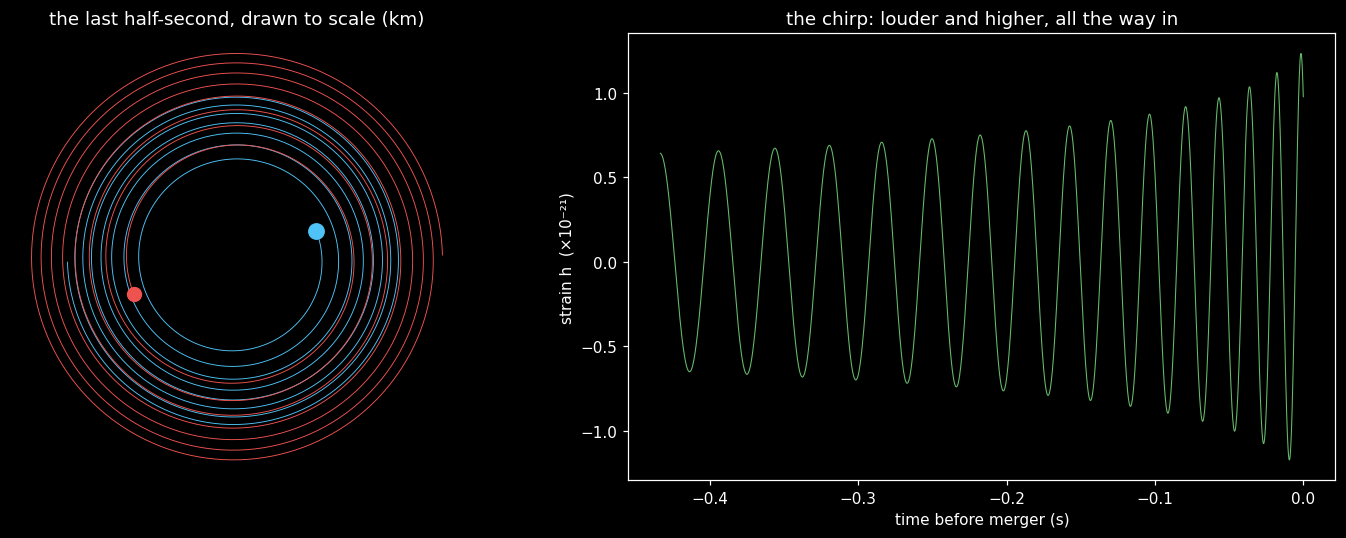

In [2]:
# the orbit itself: separation from kepler, spiralling in
a_sep = (G*Mtot/(np.pi*f)**2)**(1/3)                 # orbital separation (f_orb = f_gw/2)
phi_orb = phase/2
x1, y1 = -(m2/Mtot)*a_sep*np.cos(phi_orb), -(m2/Mtot)*a_sep*np.sin(phi_orb)
x2, y2 =  (m1/Mtot)*a_sep*np.cos(phi_orb),  (m1/Mtot)*a_sep*np.sin(phi_orb)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), facecolor='black')
axes[0].set_facecolor('black')
km = 1e3
axes[0].plot(x1/km, y1/km, color='#4fc3f7', lw=0.6)
axes[0].plot(x2/km, y2/km, color='#ef5350', lw=0.6)
axes[0].plot(x1[-1]/km, y1[-1]/km, 'o', color='#4fc3f7', ms=10)
axes[0].plot(x2[-1]/km, y2[-1]/km, 'o', color='#ef5350', ms=9)
axes[0].set_aspect('equal'); axes[0].axis('off')
axes[0].set_title("the last half-second, drawn to scale (km)", color='white')

axes[1].set_facecolor('black')
axes[1].plot(t - t_end, h*1e21, color='#66bb6a', lw=0.7)
axes[1].set_xlabel('time before merger (s)', color='white')
axes[1].set_ylabel('strain h  (×10⁻²¹)', color='white')
axes[1].tick_params(colors='white')
for s in axes[1].spines.values(): s.set_color('white')
axes[1].set_title("the chirp: louder and higher, all the way in", color='white')
plt.tight_layout(); plt.show()

In [3]:
from IPython.display import Audio, display

audio = h/np.abs(h).max()
fade = np.ones_like(audio); n_f = fs//50
fade[:n_f] = np.linspace(0, 1, n_f)
print("two black holes merging, as heard from 1.3 billion light years away:")
display(Audio(audio*fade, rate=fs))
print("and pitched up 1.5x (the famous 'shifted' version, easier on laptop speakers):")
display(Audio(audio*fade, rate=int(fs*1.5)))

two black holes merging, as heard from 1.3 billion light years away:


and pitched up 1.5x (the famous 'shifted' version, easier on laptop speakers):


In [ ]:
import urllib.request, os, h5py
from scipy import signal

# base = url here
files = {"H1": "H-H1_LOSC_4_V2-1126259446-32.hdf5",
         "L1": "L-L1_LOSC_4_V2-1126259446-32.hdf5"}
for det, fn in files.items():
    if not os.path.exists(fn):
        try:
            urllib.request.urlretrieve(base + fn, fn)
        except Exception as e:
            print(f"download failed ({e}) — grab the GW150914 32s/4kHz files "
                  f"manually from gwosc.org and place them here")
    print(f"{det}: {fn} ({os.path.getsize(fn)/1e6:.1f} MB of real spacetime)")

def load(fn):
    with h5py.File(fn, 'r') as f:
        d = f['strain/Strain']
        return d[:], d.attrs['Xstart'], d.attrs['Xspacing']

strainH, t0, dt = load(files["H1"])
strainL, _, _   = load(files["L1"])
fs_d = int(1/dt)
t_d = t0 + dt*np.arange(len(strainH))
t_event = 1126259462.44                     # published gps time of the merger
print(f"\nsample rate {fs_d} Hz, event sits {t_event-t0:.2f} s into the file")

H1: H-H1_LOSC_4_V2-1126259446-32.hdf5 (1.0 MB of real spacetime)
L1: L-L1_LOSC_4_V2-1126259446-32.hdf5 (1.0 MB of real spacetime)

sample rate 4096 Hz, event sits 16.44 s into the file


In [8]:
def whiten_bandpass(strain, fband=(35., 350.)):
    freqs, psd = signal.welch(strain, fs_d, nperseg=4*fs_d)      # the noise's fingerprint
    f_ax = np.fft.rfftfreq(len(strain), 1/fs_d)
    white = np.fft.irfft(np.fft.rfft(strain)/np.sqrt(np.interp(f_ax, freqs, psd)),
                         n=len(strain))
    b, a = signal.butter(4, [fband[0]/(fs_d/2), fband[1]/(fs_d/2)], btype='band')
    out = signal.filtfilt(b, a, white)
    quiet = (np.abs(t_d - t_event) > 1) & (t_d > t0+3) & (t_d < t0+29)
    return out / out[quiet].std()           # units of "sigmas of ordinary noise"

wH, wL = whiten_bandpass(strainH), whiten_bandpass(strainL)
near = np.abs(t_d - t_event) < 0.05
print(f"loudest excursion near the event: {np.abs(wH[near]).max():.1f} sigma (H1)")

# the famous coincidence: L1 saw it ~7 ms earlier, inverted (the detectors face
# opposite ways). find the shift ourselves by cross-correlation:
win = np.abs(t_d - t_event) < 0.05
lags = np.arange(-int(0.012*fs_d), int(0.012*fs_d))
cc = [np.dot(wH[win], np.roll(-wL, k)[win]) for k in lags]
lag = lags[np.argmax(cc)]
print(f"measured H1-L1 arrival delay: {lag/fs_d*1e3:.1f} ms (published: ~7 ms)")
print("that delay is the wave crossing the continental united states at the speed of light")

loudest excursion near the event: 8.0 sigma (H1)
measured H1-L1 arrival delay: 7.3 ms (published: ~7 ms)
that delay is the wave crossing the continental united states at the speed of light


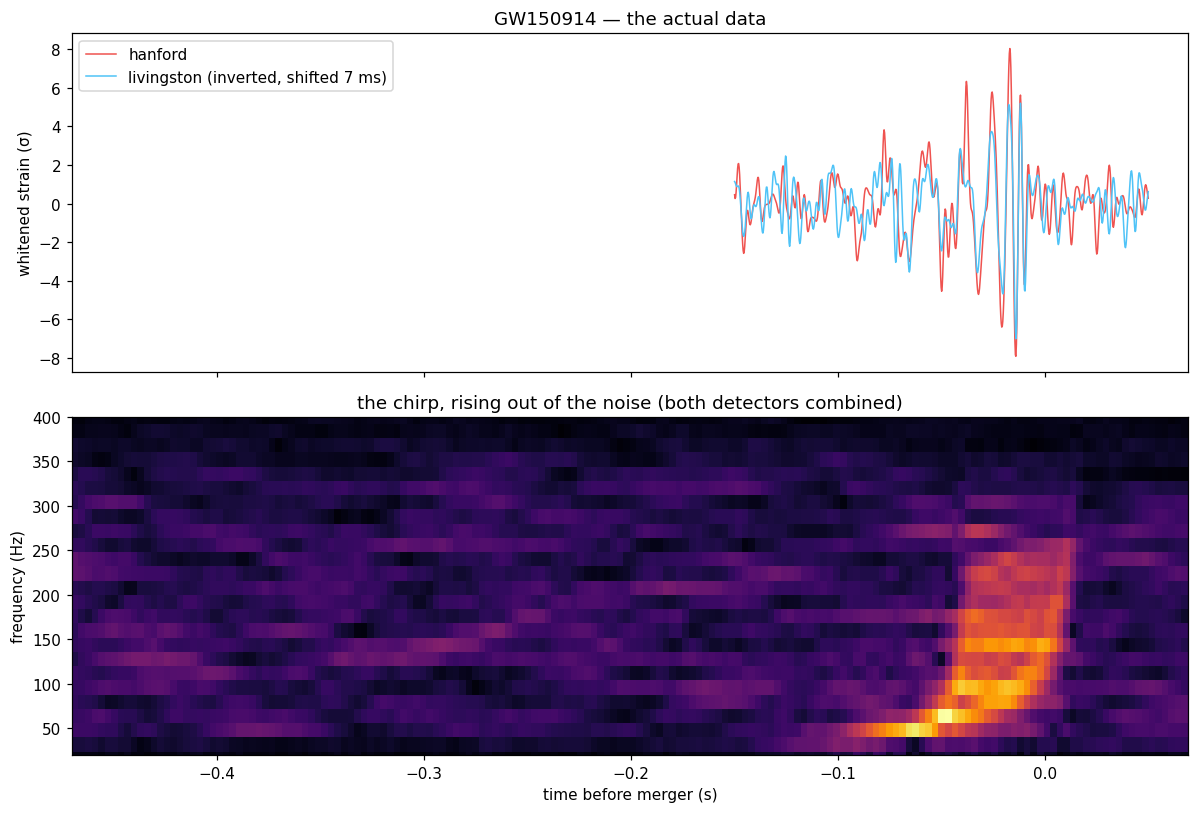


listen to the real thing (the last second, both detectors):


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
tt = t_d - t_event
m = (tt > -0.15) & (tt < 0.05)
axes[0].plot(tt[m], wH[m], color='#ef5350', lw=1, label='hanford')
axes[0].plot(tt[m], -np.roll(wL, lag)[m], color='#4fc3f7', lw=1,
             label='livingston (inverted, shifted 7 ms)')
axes[0].set_ylabel('whitened strain (σ)')
axes[0].legend(loc='upper left'); axes[0].set_title('GW150914 — the actual data')

f_sp, t_sp, SH = signal.spectrogram(wH[(tt > -0.5) & (tt < 0.1)], fs_d,
                                    nperseg=fs_d//16, noverlap=int(fs_d//16*0.95))
_,    _,    SL = signal.spectrogram(np.roll(-wL, lag)[(tt > -0.5) & (tt < 0.1)], fs_d,
                                    nperseg=fs_d//16, noverlap=int(fs_d//16*0.95))
S = SH + SL
axes[1].pcolormesh(t_sp - 0.5, f_sp, S**0.5, cmap='inferno', shading='auto')
axes[1].set_ylim(20, 400); axes[1].set_ylabel('frequency (Hz)')
axes[1].set_xlabel('time before merger (s)')
axes[1].set_title('the chirp, rising out of the noise (both detectors combined)')
plt.tight_layout(); plt.show()

print("\nlisten to the real thing (the last second, both detectors):")
seg = (tt > -0.9) & (tt < 0.1)
display(Audio((wH[seg] - np.roll(wL, lag)[seg]), rate=fs_d))

chirp mass, measured from the real data by us, just now: 31 suns
the LIGO collaboration's value:                            ~30 suns

(for equal masses that implies a total of ~72 suns of black hole — published: 36 + 29 = 65)


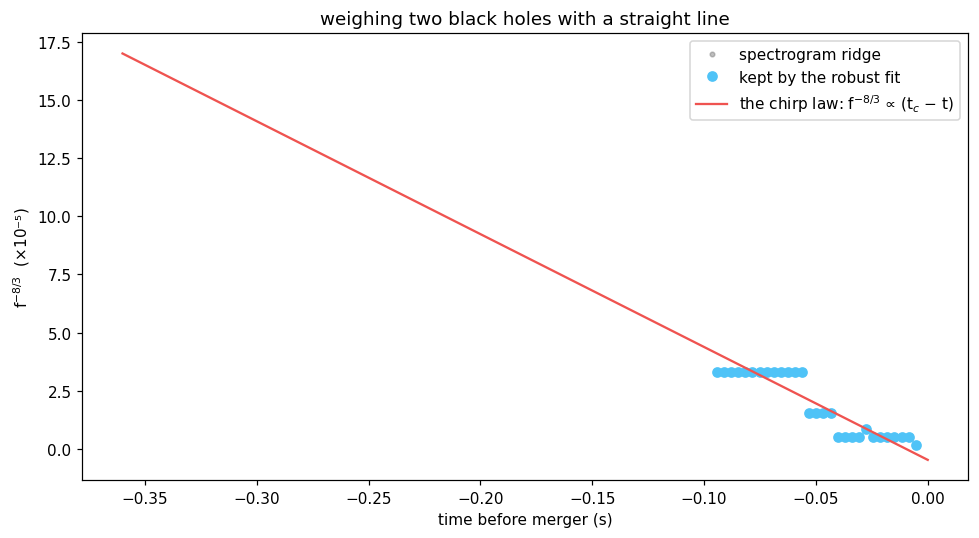

In [10]:
band = (f_sp > 35) & (f_sp < 320)
fb, Sb = f_sp[band], S[band]
ridge_i = np.argmax(Sb, axis=0)
ridge_f = fb[ridge_i]
ridge_p = Sb[ridge_i, np.arange(Sb.shape[1])]
ridge_t = t_sp - 0.5

sel = (ridge_t > -0.35) & (ridge_t < -0.005) & (ridge_p > np.median(Sb)*6)
x, y, wgt = ridge_t[sel], ridge_f[sel]**(-8/3), ridge_p[sel]
for _ in range(4):                                   # robust fit: drop outliers, refit
    A = np.polyfit(x, y, 1, w=np.sqrt(wgt))
    res = y - np.polyval(A, x)
    keep = np.abs(res) < 2*res.std()
    x, y, wgt = x[keep], y[keep], wgt[keep]

K = -A[0]
Mc_measured = (K*3/8/((96/5)*np.pi**(8/3)))**(3/5) * c**3/G
print(f"chirp mass, measured from the real data by us, just now: {Mc_measured/Msun:.0f} suns")
print(f"the LIGO collaboration's value:                            ~30 suns")
print(f"\n(for equal masses that implies a total of ~{2**(6/5)*Mc_measured/Msun:.0f} suns "
      f"of black hole — published: 36 + 29 = 65)")

plt.figure(figsize=(9, 5))
plt.plot(ridge_t[sel], ridge_f[sel]**(-8/3)*1e5, '.', color='gray', alpha=0.5,
         label='spectrogram ridge')
plt.plot(x, y*1e5, 'o', color='#4fc3f7', label='kept by the robust fit')
tf = np.linspace(-0.36, 0.0, 10)
plt.plot(tf, np.polyval(A, tf)*1e5, color='#ef5350', label='the chirp law: f$^{-8/3}$ ∝ (t$_c$ − t)')
plt.xlabel('time before merger (s)'); plt.ylabel('f$^{-8/3}$  (×10⁻⁵)')
plt.title('weighing two black holes with a straight line')
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
A_before = 36**2 + 29**2      # horizon areas, in units where A ~ M^2
A_after  = 62**2
print(f"total horizon area before: {A_before}   after: {A_after}")
print(f"three suns of mass destroyed, and the area still grew by {100*(A_after/A_before-1):.0f}%")
print("the area theorem does not lose. (chapter five sends its regards)")

# the newborn hole's first cry: the ringdown, a single dying tone
M_f, a_f = 62*Msun, 0.67
f_ring = c**3/(2*np.pi*G*M_f) * (1 - 0.63*(1-a_f)**0.3)      # standard kerr QNM fit
Q = 2*(1-a_f)**(-0.45)
tau = Q/(np.pi*f_ring)
print(f"\nringdown of the final hole: a {f_ring:.0f} Hz tone dying in {tau*1e3:.0f} ms")

total horizon area before: 2137   after: 3844
three suns of mass destroyed, and the area still grew by 80%
the area theorem does not lose. (chapter five sends its regards)

ringdown of the final hole: a 286 Hz tone dying in 4 ms
